# Develop model for patching image and test end2end with pipeline
> Create a model which patch image , do preprocesing, unpatch and do postprocessing

In [ ]:
#| default_exp patching.model_development

In [ ]:
#| hide
%load_ext autoreload
%autoreload 2


In [ ]:
import albumentations as A

C:\Users\goni\AppData\Roaming\Python\Python312\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


In [ ]:
A.__version__

'2.0.5'

In [ ]:
#| export
import sys
from pathlib import Path
from fastcore.script import *
from fastcore.all import *
from torch import nn
import torch
import torch.nn.functional as F
import time
#try:
    #import onnxruntime as ort
#except ImportError:
    #print("Installing onnxruntime...")
    #import subprocess
    #subprocess.check_call(["pip", "install", "onnxruntime"])
    #import onnxruntime as ort

from private_front_easy_pin_detection.dataloader_creation import *


In [ ]:
#| exporti
from new_test.patching.preprocessing_input_image import *
#from private_front_easy_pin_detection.model_development import *

In [ ]:
#| export
CV_TOOLS = Path(r'/home/ai_sintercra/homes/hasan/projects/git_data/cv_tools')
sys.path.append(str(CV_TOOLS))


In [ ]:
#| export
custom_lib_path = Path(r'/home/ai_warstein/homes/goni/custom_libs')
sys.path.append(str(custom_lib_path))


In [ ]:
#| export
from cv_tools.imports import *
from cv_tools.core import *
from dotenv import load_dotenv


In [ ]:
#| export
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import Tensor

In [ ]:
#| export
load_dotenv(dotenv_path=f'/home/ai_sintercra/homes/hasan/projects/git_data/new_test/new_test/.env')

False

In [ ]:
#| exporti
from new_test.patching.preprocessing_input_image import *

In [ ]:
#| export
class SpatialAttention(nn.Module):
    def __init__(self, in_channels):
        super(SpatialAttention, self).__init__()
        self.conv = nn.Conv2d(in_channels, 1, kernel_size=1)
        
    def forward(self, x):
        # Generate attention map
        attention = self.conv(x)
        attention = torch.sigmoid(attention)
        
        # Apply attention
        return x * attention

In [ ]:
#| export
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, stride=1, padding=1):
        super(DepthwiseSeparableConv, self).__init__()
        self.depthwise = nn.Conv2d(
            in_channels, in_channels, kernel_size=kernel_size,
            stride=stride, padding=padding, groups=in_channels, bias=False
        )
        self.pointwise = nn.Conv2d(
            in_channels, out_channels, kernel_size=1, bias=True
        )
        
    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return x

In [ ]:
#| export
class EncoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_depthwise=False):
        super(EncoderBlock, self).__init__()
        
        if use_depthwise:
            self.conv1 = DepthwiseSeparableConv(in_channels, out_channels)
            self.conv2 = DepthwiseSeparableConv(out_channels, out_channels)
        else:
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU6(inplace=True)
        
    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        return x

In [ ]:
#| export
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, out_channels, use_depthwise=False):
        super(DecoderBlock, self).__init__()
        
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        if use_depthwise:
            self.conv1 = DepthwiseSeparableConv(in_channels, out_channels)
            self.conv2 = DepthwiseSeparableConv(out_channels, out_channels)
        else:
            self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)
            self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU6(inplace=True)
        self.attention = SpatialAttention(out_channels)
        
    def forward(self, x, skip):
        x = self.up(x)
        
        # Handle cases where dimensions don't match exactly
        diffY = skip.size()[2] - x.size()[2]
        diffX = skip.size()[3] - x.size()[3]
        
        x = F.pad(x, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        
        # Concatenate skip connection
        x = torch.cat([skip, x], dim=1)
        
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.attention(x)
        
        return x

In [ ]:
#| export
class LightweightAttentionUNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super(LightweightAttentionUNet, self).__init__()
        
        # Initial number of filters (reduced from standard U-Net)
        init_features = 16
        
        # Encoder path
        self.encoder1 = EncoderBlock(in_channels, init_features)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder2 = EncoderBlock(init_features, init_features*2)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.encoder3 = EncoderBlock(init_features*2, init_features*4, use_depthwise=True)
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2)
        
        # Bottleneck
        self.bottleneck = EncoderBlock(init_features*4, init_features*8, use_depthwise=True)
        
        # Decoder path
        self.decoder3 = DecoderBlock(init_features*8 + init_features*4, init_features*4, use_depthwise=True)
        self.decoder2 = DecoderBlock(init_features*4 + init_features*2, init_features*2)
        self.decoder1 = DecoderBlock(init_features*2 + init_features, init_features)
        
        # Final output layer
        self.final_conv = nn.Conv2d(init_features, out_channels, kernel_size=1)
        
    def forward(self, x):
        # Encoder
        enc1 = self.encoder1(x)
        x = self.pool1(enc1)
        
        enc2 = self.encoder2(x)
        x = self.pool2(enc2)
        
        enc3 = self.encoder3(x)
        x = self.pool3(enc3)
        
        # Bottleneck
        x = self.bottleneck(x)
        
        # Decoder
        x = self.decoder3(x, enc3)
        x = self.decoder2(x, enc2)
        x = self.decoder1(x, enc1)
        
        # Final output
        x = self.final_conv(x)
        
        #return torch.sigmoid(x)  # Sigmoid for binary segmentation
        return x

    def get_input_names(self):
        return ['input']
        
    def get_output_names(self):
        return ['output']
        
    def get_dynamic_axes(self):
        return {
            'input': {0: 'batch_size', 2: 'height', 3: 'width'},
            'output': {0: 'batch_size', 2: 'height', 3: 'width'}
        }
        
    def get_dummy_input(self, batch_size=1, height=1152, width=1632):
        return torch.randn(batch_size, 1, height, width)

In [ ]:
model = LightweightAttentionUNet(
    in_channels=1,
    out_channels=1
)

In [ ]:
model(torch.rand(40, 1, 256, 256)).shape

torch.Size([40, 1, 256, 256])

In [ ]:
IMG_HEIGHT = 1152
IMG_WIDTH = 1632

IMG_HEIGHT = 256
IMG_WIDTH = 256
img = model.get_dummy_input(
    batch_size=1, 
    height=IMG_HEIGHT, 
    width=IMG_WIDTH)
dummy_output = model(img)
print(dummy_output.shape)

torch.Size([1, 1, 256, 256])


In [ ]:
if system() == 'Windows':
    patch_image_data = Path(r'E:\CurrentTrainingData20240812_trn_val\training_zero_degree_solder_pin\train\patch300_images')
    patch_mask_data = Path(r'E:\CurrentTrainingData20240812_trn_val\training_zero_degree_solder_pin\train\patch300_masks')
else:
    patch_image_data = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/training_zero_degree_solder_pin/train/patch300_images')
    patch_mask_data = Path(r'/home/ai_easypid.work/CurrentTrainingData20240812_trn_val/training_zero_degree_solder_pin/train/patch300_masks')
#patch_images = patch_image_data.ls()
#patch_masks = patch_mask_data.ls()



In [ ]:
len(patch_images), len(patch_masks)

NameError: name 'patch_images' is not defined

In [ ]:
sm_p_img = patch_images[0]
sm_p_img = read_img(sm_p_img)
sn_p_img_n = Tensor(sm_p_img/255.)
sn_p_img_n.max(), sn_p_img_n.min()

(tensor(1.), tensor(0.))

In [ ]:
np.save('cache/sample_patch_image.npy', sm_p_img)

In [ ]:
Path('cache').ls()

(#4) [Path('cache/mask_stats'),Path('cache/sample_img.npy'),Path('cache/sample_msks.npy'),Path('cache/smaple_patch_image.png.npy')]

In [ ]:
img_ = np.load('cache/sample_patch_image.npy')

In [ ]:
#| export
def np_to_torch(x):
   'float -> 1,1,img_size -> Tensor'
   #x:[0,1]
   x = x.astype(np.float32)
   x = x[None, None,...]
   x = Tensor(x)
   return x

In [ ]:
pt_img = np_to_torch(img_)

In [ ]:
pt_img_batch = torch.randn(40, 1, 256, 256)

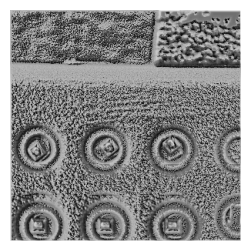

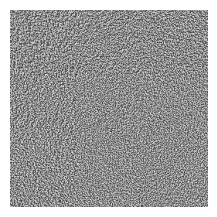

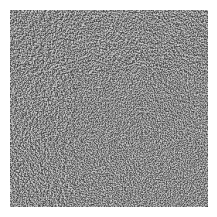

In [ ]:
clahe = ONNXFriendlyCLAHEOpset12(
    window_size=8,
    clip_limit=4.0,
    eps=1e-6
)
clahe_img = clahe(pt_img)
clahe_img_batch = clahe(pt_img_batch)
show_(clahe_img[0,0,:])
show_(clahe_img_batch[0,0,:])
show_(clahe_img_batch[1,0,:,:])


In [ ]:

bias_field_correction = BiasFieldCorrectionLayer(
    in_channels=1,
    reduction=16
)
bias_correction_images = bias_field_correction(torch.rand(40, 1, 256, 256))
bias_correction_images.shape

torch.Size([40, 1, 256, 256])

In [ ]:

cl_img = cl(sn_p_img_n[None, None, ...])
denoised_img = denoise(cl_img)
bias_field_corrected_img = bias_field_correction(
    denoised_img)
show_(cl_img[0,0,:,:])
show_(denoised_img[0,0,:,:])
show_(bias_field_corrected_img[0,0,:,:].detach().numpy())
#show_(bias_field_corrected_img[0,0,:,:])

NameError: name 'cl' is not defined

In [ ]:
#| export
class ModelWithPreprocessing(nn.Module):
    def __init__(
        self, 
        in_channels:int=1,  # number of channels in the input image
        out_channels:int=1, # number of channels in the output image
        with_clahe:bool=True, # whether to apply clahe
        with_denoise:bool=True, # whether to apply denoise
        with_bias_field_correction:bool=True, # whether to apply bias field correction
    ):
        """
        Model with preprocessing + postprocessing + tiling.
        """
        super(ModelWithPreprocessing, self).__init__()
        self.in_channels = in_channels
        self.out_channels = out_channels
        self.with_clahe = with_clahe
        self.with_denoise = with_denoise
        self.with_bias_field_correction = with_bias_field_correction

        # clahe
        
        self.cl = ONNXFriendlyCLAHEOpset12(
            window_size=8,
            clip_limit=2.0,
        )
        # blurring 
        self.denoise = GaussianDenoiseLayer(
            kernel_size=5,
            sigma=1.0,
            channels=1
        )
        # bias field correction
        self.bias_field_correction = BiasFieldCorrectionLayer(
            in_channels=1,
            reduction=16
        )
        self.model = LightweightAttentionUNet(
            in_channels=self.in_channels,
            out_channels=self.out_channels
        )
    __repr__ = basic_repr()
        
    def forward(self, x):
        if self.with_clahe:
            x = self.cl(x)
        if self.with_denoise:
            x = self.denoise(x)
        if self.with_bias_field_correction:
            x = self.bias_field_correction(x)
        x = self.model(x)
        
            
        return x

In [ ]:
#| export
class ModelForTraining(nn.Module):
    """Model wrapper optimized for training with proper loss computation and memory efficiency.
    
    Key features for training:
    - Disabled tiling to reduce memory overhead during backprop
    - Disabled postprocessing for faster forward passes
    - Direct output suitable for loss computation
    - Maintains all preprocessing steps for data consistency
    """
    def __init__(self, 
                 in_channels=1, 
                 out_channels=1,
                 with_clahe=True,
                 with_denoise=True, 
                 with_bias_field_correction=True):
        super(ModelForTraining, self).__init__()
        self.model = ModelWithPreprocessing(
            in_channels=in_channels,
            out_channels=out_channels,
            with_clahe=with_clahe,
            with_denoise=with_denoise,
            with_bias_field_correction=with_bias_field_correction
        )
        
    def forward(self, x):
        """Forward pass optimized for training.
        
        Args:
            x: Input tensor of shape (B, C, H, W)
            
        Returns:
            Raw model output suitable for loss computation
        """
        return self.model(x)
    
    def training_step(self, batch, criterion):
        """Convenience method for training step.
        
        Args:
            batch: Tuple of (images, masks)
            criterion: Loss function (e.g., BCEWithLogitsLoss)
            
        Returns:
            loss: Computed loss value
        """
        images, masks = batch
        outputs = self.forward(images)
        loss = criterion(outputs, masks)
        return loss


In [ ]:
model_ = ModelForTraining(
    in_channels=1,
    out_channels=1,
    with_clahe=True,
    with_denoise=True,
    with_bias_field_correction=True
)

In [ ]:
m_with_preprocessing = ModelWithPreprocessing(
    in_channels=1,
    out_channels=1,
)

In [ ]:
img = torch.randn(40,1,256, 256)
output = m_with_preprocessing(img)

In [ ]:
output.shape

torch.Size([40, 1, 256, 256])

In [ ]:
from private_front_easy_pin_detection.model_development import *

In [ ]:
only_model = LightweightAttentionUNet(
    in_channels=1,
    out_channels=1
)

In [ ]:
#| export
def get_end_test_only_model(
    in_channels=1,
    out_channels=1
):
    return LightweightAttentionUNet(
        in_channels=in_channels,
        out_channels=out_channels
    )

In [ ]:
#| export
def export_model_to_onnx(
    model, # nn.Module: PyTorch model to export
    output_path, # str: Path to save ONNX model
    input_shape=(1, 1, 1152, 1632), # tuple: Shape of input tensor
    input_names=None, # list: Names of input tensors
    output_names=None, # list: Names of output tensors
    dynamic_axes=None # dict: Dynamic axes for inputs and outputs
    )->str: # Path to exported ONNX model
    """
    Export PyTorch model to ONNX format.
    
    """
    # Create dummy input
    dummy_input = torch.randn(input_shape)
    
    # Set default input and output names if not provided
    if input_names is None:
        input_names = ['input']
    if output_names is None:
        output_names = ['output']
    
    ## Set default dynamic axes if not provided
    #if dynamic_axes is None:
        #dynamic_axes = {
            #'input': {0: 'batch_size', 2: 'height', 3: 'width'},
            #'output': {0: 'batch_size', 2: 'height', 3: 'width'}
        #}
    
    # Export model to ONNX
    torch.onnx.export(
        model,                       # PyTorch model
        dummy_input,                 # Dummy input
        output_path,                 # Output path
        export_params=True,          # Export model parameters
        opset_version=12,            # ONNX opset version
        do_constant_folding=True,    # Fold constants
        input_names=input_names,     # Input names
        output_names=output_names,   # Output names
        verbose=False                # Verbose output
    )
    
    return output_path

In [ ]:
onnx_output_path = Path(r'E:\CurrentTrainingData20240812_trn_val\training_zero_degree_solder_pin\train\models\model_with_preprocessing_tiling.onnx')
Path(onnx_output_path.parent).mkdir(exist_ok=True, parents=True)
export_model_to_onnx(
    model=m_with_preprocessing,
    output_path=onnx_output_path,
    input_shape=(1, 1, 1152, 1632),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes=None
)


C:\Users\goni\AppData\Local\Temp\ipykernel_8244\1796802817.py:54: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  'laplacian': torch.tensor([[-1,-1,-1], [-1,8,-1], [-1,-1,-1]], dtype=torch.float32),
C:\Users\goni\AppData\Local\Temp\ipykernel_8244\1796802817.py:55: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  'sobel_h': torch.tensor([[-1,-2,-1], [0,0,0], [1,2,1]], dtype=torch.float32),
C:\Users\goni\AppData\Local\Temp\ipykernel_8244\1796802817.py:56: TracerWarning: torch.tensor r

Path('E:/CurrentTrainingData20240812_trn_val/training_zero_degree_solder_pin/train/models/model_with_preprocessing_tiling.onnx')

In [ ]:
###| export
def optimize_onnx_model(input_path, output_path=None):
    """
    Optimize ONNX model for inference.
    
    Args:
        input_path (str): Path to input ONNX model
        output_path (str, optional): Path to save optimized ONNX model
        
    Returns:
        str: Path to optimized ONNX model
    """
    # Set default output path if not provided
    if output_path is None:
        output_path = input_path.replace('.onnx', '_optimized.onnx')
    
    # Load ONNX model
    model = onnx.load(input_path)
    
    # Check model validity
    onnx.checker.check_model(model)
    
    # Optimize model
    from onnxruntime.transformers import optimizer
    optimized_model = optimizer.optimize_model(
        input_path,
        model_type='conv',
        num_heads=0,
        hidden_size=0
    )
    
    # Save optimized model
    optimized_model.save_model_to_file(output_path)
    
    return output_path

In [ ]:
###| export
def test_onnx_model_performance(
    model_path, 
    input_shape=(1, 1, 256, 256), 
    num_runs=10):
    """
    Test ONNX model performance.
    
    Args:
        model_path (str): Path to ONNX model
        input_shape (tuple): Shape of input tensor
        num_runs (int): Number of runs for performance testing
        
    Returns:
        dict: Performance metrics with times in seconds
    """
    # Create ONNX runtime session
    session = ort.InferenceSession(model_path)
    
    # Get input and output names
    input_name = session.get_inputs()[0].name
    output_name = session.get_outputs()[0].name
    
    # Create random input data
    input_data = np.random.randint(0, 256, input_shape).astype(np.float32)
    print(f"Input shape: {input_data.shape}")
    
    # Warm-up run
    output = session.run([output_name], {input_name: input_data})
    print(f"Output shape: {output[0].shape}")
    
    # Performance testing
    inference_times = []
    for _ in range(num_runs):
        start_time = time.time()
        output = session.run([output_name], {input_name: input_data})
        inference_times.append(time.time() - start_time)
        print(f"Output shape: {output[0].shape}")
    
    # Calculate performance metrics
    avg_time = np.mean(inference_times)
    min_time = np.min(inference_times)
    max_time = np.max(inference_times)
    
    print(f"Average inference time: {avg_time:.4f} seconds")
    print(f"Minimum inference time: {min_time:.4f} seconds")
    print(f"Maximum inference time: {max_time:.4f} seconds")
    print(f"FPS: {1.0/avg_time:.2f}")
    
    return {
        'average_time_seconds': avg_time,
        'min_time_seconds': min_time,
        'max_time_seconds': max_time,
        'fps': 1.0 / avg_time
    }

In [ ]:
onnx_output_path = Path(r'E:\CurrentTrainingData20240812_trn_val\training_zero_degree_solder_pin\train\models\model_with_preprocessing.onnx')
Path(onnx_output_path.parent).mkdir(exist_ok=True, parents=True)
export_model_to_onnx(
    model=m_with_preprocessing,
    output_path=onnx_output_path,
    input_shape=(1, 1, 1152, 1632),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes=None
)


\\vihsdv140.infineon.com\ai_sintercra\homes\hasan\projects\git_data\new_test\new_test\patching\preprocessing_input_image.py:358: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  # Strong edge enhancement using Laplacian approximation
\\vihsdv140.infineon.com\ai_sintercra\homes\hasan\projects\git_data\new_test\new_test\patching\preprocessing_input_image.py:821: TracerWarning: Converting a tensor to a Python boolean might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  # Calculate padding amounts
\\vihsdv140.infineon.com\ai_sintercra\homes\hasan\projects\git_data\new_test\new_test\

TypeError: TileMergerv4.forward() takes from 5 to 6 positional arguments but 7 were given

In [ ]:
test_onnx_model_performance(
    model_path=onnx_output_path,
    input_shape=(1,1,1152,1632),
    num_runs=10
)

Input shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Output shape: (1, 1, 1152, 1632)
Average inference time: 1.0281 seconds
Minimum inference time: 0.7371 seconds
Maximum inference time: 1.4805 seconds
FPS: 0.97


{'average_time_seconds': np.float64(1.028063464164734),
 'min_time_seconds': np.float64(0.7370705604553223),
 'max_time_seconds': np.float64(1.4804766178131104),
 'fps': np.float64(0.9727025955663793)}

In [ ]:
#| export
CURRETNT_NB='/home/ai_sintercra/homes/hasan/projects/git_data/new_test/nbs'

In [ ]:
#| hide
import nbdev; nbdev.nbdev_export('46_patching.model_development.ipynb')

ValueError: '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\nbs\\39_preprocessing.zero_degree_solder_pin.ipynb' is not in the subpath of '\\\\vihsdv140.infineon.com\\ai_sintercra\\homes\\hasan\\projects\\git_data\\new_test\\nbs'